In [3]:
import os
import re
import json
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import exposure, morphology, filters, measure
from skimage.filters import frangi
from skimage.morphology import skeletonize, disk
from scipy.ndimage import distance_transform_edt
from pathlib import Path
from config import RAW_IMG_DIR

In [15]:
@dataclass
class PipelineConfig:
    # Preprocessing
    clahe_clip_limit: float = 2.0
    clahe_tile_grid: Tuple[int, int] = (8, 8)
    bilateral_d: int = 9
    bilateral_sigma_color: float = 75.0
    bilateral_sigma_space: float = 75.
    # Non-Local Means denoising
    nlm_h: float = 10.0               # filter strength — tune between 6–15
    nlm_template_window: int = 7      # patch size for comparison (7 = 7×7)
    nlm_search_window: int = 21       # search area (21 = 21×21)

    # Frangi vesselness
    frangi_scale_range: Tuple[float, float] = (1.0, 5.0)
    frangi_scale_step: float = 0.5
    frangi_beta: float = 0.5          # sensitivity to blob-like structures
    frangi_gamma: float = 15.0        # sensitivity to background noise

    # Binarisation
    vessel_threshold_method: str = "otsu"   # "otsu" | "adaptive" | "manual"
    vessel_threshold_value: float = 0.03    # used only when method="manual"
    vessel_min_area: int = 100              # remove tiny components

    # ROI extraction
    roi_size: int = 64                      # square window side (px)
    roi_stride: int = 8                     # skeleton sampling step (px)
    min_neg_distance: int = 20             # min distance from GT box centre for negatives
    balance_ratio: float = 1.0             # negatives / positives ratio after balancing

    # Paths
    dataset_root: str = "dataset"
    output_root: str = "rois"

CFG = PipelineConfig()
print("✓ Configuration loaded")

✓ Configuration loaded


In [16]:
# ─────────────────────────────────────────────
# CELL 2 — Dataset utilities
# ─────────────────────────────────────────────

def iter_frames(dataset_root: str):
    """
    Yield (patient_id, session_id, frame_path) for every PNG in the dataset.
    Expected tree: dataset_root / patient / session / *.png
    """
    root = Path(dataset_root)
    for patient_dir in sorted(root.iterdir()):
        if not patient_dir.is_dir():
            continue
        for session_dir in sorted(patient_dir.iterdir()):
            if not session_dir.is_dir():
                continue
            for img_path in sorted(session_dir.glob("*.png")):
                yield patient_dir.name, session_dir.name, img_path


def load_annotations_xml(annotation_path: Path) -> List[Tuple[int,int,int,int]]:
    """
    Parse a PASCAL-VOC style XML annotation file.
    Returns list of (x_min, y_min, x_max, y_max) bounding boxes.
    Adjust tag names to match your actual annotation format.
    """
    boxes = []
    if not annotation_path.exists():
        return boxes
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))
        boxes.append((xmin, ymin, xmax, ymax))
    return boxes


def load_annotations_json(annotation_path: Path) -> List[Tuple[int,int,int,int]]:
    """
    Parse a COCO-style JSON annotation (per-image sidecar).
    Adjust keys to match your format.
    """
    boxes = []
    if not annotation_path.exists():
        return boxes
    with open(annotation_path) as f:
        data = json.load(f)
    for ann in data.get("annotations", []):
        x, y, w, h = ann["bbox"]
        boxes.append((int(x), int(y), int(x+w), int(y+h)))
    return boxes


def load_annotation(frame_path: Path) -> List[Tuple[int,int,int,int]]:
    """
    Auto-detect annotation format (XML or JSON) next to the frame.
    """
    for ext, loader in [(".xml", load_annotations_xml), (".json", load_annotations_json)]:
        ann_path = frame_path.with_suffix(ext)
        if ann_path.exists():
            return loader(ann_path)
    return []


print("✓ Dataset utilities defined")

✓ Dataset utilities defined


In [18]:
# ─────────────────────────────────────────────
# CELL 3 — Stage 2: Preprocessing
# ─────────────────────────────────────────────

def load_gray(img_path: Path) -> np.ndarray:
    """Load a PNG as uint8 grayscale."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    return img


def apply_clahe(img: np.ndarray, cfg: PipelineConfig = CFG) -> np.ndarray:
    """
    Step 2 — CLAHE (Contrast Limited Adaptive Histogram Equalisation).
    Enhances local contrast, making vessel boundaries more visible.
    """
    clahe = cv2.createCLAHE(
        clipLimit=cfg.clahe_clip_limit,
        tileGridSize=cfg.clahe_tile_grid
    )
    return clahe.apply(img)


def apply_bilateral(img: np.ndarray, cfg: PipelineConfig = CFG) -> np.ndarray:
    """
    Step 3 — Bilateral filter.
    Smooths noise while preserving vessel edges.
    """
    return cv2.bilateralFilter(
        img,
        d=cfg.bilateral_d,
        sigmaColor=cfg.bilateral_sigma_color,
        sigmaSpace=cfg.bilateral_sigma_space
    )

def apply_denoising(img: np.ndarray, cfg: PipelineConfig = CFG) -> np.ndarray:
    """
    Step 3 — Non-Local Means denoising.
    Superior to bilateral for angiographic images because it leverages
    non-local self-similarity along vessel segments.

    h           : filter strength (higher = smoother, more detail loss)
    templateWindowSize : size of patch used for similarity comparison (odd)
    searchWindowSize   : neighbourhood to search for similar patches (odd)
    """
    return cv2.fastNlMeansDenoising(
        img,
        h=cfg.nlm_h,
        templateWindowSize=cfg.nlm_template_window,
        searchWindowSize=cfg.nlm_search_window,
    )

def preprocess(img_path: Path, cfg: PipelineConfig = CFG) -> np.ndarray:
    """
    Full preprocessing pipeline for one frame.
    Returns preprocessed uint8 grayscale image.

    Pipeline:
        load → CLAHE → bilateral filter
    Note: Gamma / histogram matching (Step 1) can be added here if needed,
          but CLAHE already handles contrast normalisation in most cases.
          Uncomment the gamma block below to activate it.
    """
    img = load_gray(img_path)

    # ── Optional: gamma correction ──────────────
    # gamma = 1.2
    # img = exposure.adjust_gamma(img, gamma)
    # img = (img * 255).astype(np.uint8)   # if skimage returns float
    # ─────────────────────────────────────────────

    img = apply_clahe(img, cfg)
    # img = apply_bilateral(img, cfg)
    img = apply_denoising(img, cfg)
    return img


def show_preprocessing(img_path: Path, cfg: PipelineConfig = CFG):
    """Visualise each preprocessing step side by side."""
    raw   = load_gray(img_path)
    clahe = apply_clahe(raw, cfg)
    final = apply_bilateral(clahe, cfg)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, im, title in zip(axes, [raw, clahe, final],
                              ["Original", "After CLAHE", "After Bilateral"]):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("✓ Preprocessing functions defined")

✓ Preprocessing functions defined


In [19]:
# ─────────────────────────────────────────────
# CELL 4 — Stage 3a: Vessel segmentation
# ─────────────────────────────────────────────

def apply_frangi(img: np.ndarray, cfg: PipelineConfig = CFG) -> np.ndarray:
    """
    Step 1 — Frangi vesselness filter.
    Returns a float [0,1] vesselness map; bright = tubular vessel-like structure.

    The Frangi filter analyses the Hessian eigenvalues at each pixel to identify
    curvilinear structures across multiple scales.
    """
    img_float = img.astype(np.float64) / 255.0
    scales = np.arange(
        cfg.frangi_scale_range[0],
        cfg.frangi_scale_range[1] + cfg.frangi_scale_step,
        cfg.frangi_scale_step
    )
    vessel_map = frangi(
        img_float,
        sigmas=scales,
        beta=cfg.frangi_beta,
        gamma=cfg.frangi_gamma,
        black_ridges=False    # coronary vessels are bright on dark background
    )
    # Normalise to [0, 1]
    v_min, v_max = vessel_map.min(), vessel_map.max()
    if v_max > v_min:
        vessel_map = (vessel_map - v_min) / (v_max - v_min)
    return vessel_map.astype(np.float32)


def binarise_vessels(vessel_map: np.ndarray, cfg: PipelineConfig = CFG) -> np.ndarray:
    """
    Step 2 — Threshold the vesselness map to obtain a binary vessel mask.
    Returns uint8 mask (0 / 255).
    """
    vm8 = (vessel_map * 255).astype(np.uint8)

    if cfg.vessel_threshold_method == "otsu":
        _, binary = cv2.threshold(vm8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif cfg.vessel_threshold_method == "adaptive":
        binary = cv2.adaptiveThreshold(
            vm8, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 31, -2
        )
    else:  # manual
        thresh = int(cfg.vessel_threshold_value * 255)
        _, binary = cv2.threshold(vm8, thresh, 255, cv2.THRESH_BINARY)

    # Morphological cleanup — close small gaps, remove specks
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel, iterations=1)

    # Remove tiny connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)
    clean = np.zeros_like(binary)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= cfg.vessel_min_area:
            clean[labels == lbl] = 255
    return clean


def skeletonise_vessels(binary_mask: np.ndarray) -> np.ndarray:
    """
    Step 3 — Skeletonise the vessel binary mask.
    Returns a boolean array where True = centreline pixel.
    """
    bool_mask = binary_mask > 0
    skeleton  = skeletonize(bool_mask)
    return skeleton


def segment_vessels(preprocessed: np.ndarray, cfg: PipelineConfig = CFG
                    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the full vessel segmentation chain on a preprocessed frame.

    Returns:
        vessel_map  — float32 Frangi vesselness map
        binary_mask — uint8 binary vessel mask
        skeleton    — bool array (centreline)
    """
    vessel_map   = apply_frangi(preprocessed, cfg)
    binary_mask  = binarise_vessels(vessel_map, cfg)
    skeleton     = skeletonise_vessels(binary_mask)
    return vessel_map, binary_mask, skeleton


def show_segmentation(img_path: Path, cfg: PipelineConfig = CFG):
    """Visualise the full segmentation chain for one frame."""
    prep = preprocess(img_path, cfg)
    vmap, bmask, skel = segment_vessels(prep, cfg)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, im, cmap, title in zip(
        axes,
        [prep, vmap, bmask, skel.astype(np.uint8)*255],
        ["gray","hot","gray","gray"],
        ["Preprocessed","Frangi vesselness","Binary mask","Skeleton"]
    ):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("✓ Vessel segmentation functions defined")

✓ Vessel segmentation functions defined


In [20]:
# ─────────────────────────────────────────────
# CELL 5 — Stage 3b: ROI extraction & labelling
# ─────────────────────────────────────────────

def sample_skeleton_points(skeleton: np.ndarray, stride: int = CFG.roi_stride
                           ) -> np.ndarray:
    """
    Return an (N, 2) array of (row, col) skeleton centreline points,
    sub-sampled every `stride` pixels to avoid redundant windows.
    """
    ys, xs = np.where(skeleton)
    coords  = np.column_stack([ys, xs])
    if len(coords) == 0:
        return coords
    # Simple stride sub-sampling along raster order
    return coords[::stride]


def point_in_box(r: int, c: int, box: Tuple[int,int,int,int], half: int) -> bool:
    """
    Return True if the ROI window centred at (r,c) overlaps the GT bounding box.
    box = (xmin, ymin, xmax, ymax)  [x=col, y=row convention]
    """
    xmin, ymin, xmax, ymax = box
    win_xmin = c - half
    win_ymin = r - half
    win_xmax = c + half
    win_ymax = r + half
    # Intersection check
    return not (win_xmax < xmin or win_xmin > xmax or
                win_ymax < ymin or win_ymin > ymax)


def label_point(r: int, c: int,
                boxes: List[Tuple[int,int,int,int]],
                half: int,
                min_neg_dist: int) -> Optional[int]:
    """
    Return:
        1   — positive (window overlaps a GT box)
        0   — certain negative (window centre is ≥ min_neg_dist from all GT boxes)
        None — uncertain / border region → skip
    """
    if not boxes:
        return 0  # no annotations → everything is negative

    for box in boxes:
        if point_in_box(r, c, box, half):
            return 1  # overlaps at least one stenosis

    # Compute min distance from (c,r) to any GT box centre
    min_dist = min(
        np.hypot(c - (b[0]+b[2])/2, r - (b[1]+b[3])/2)
        for b in boxes
    )
    if min_dist >= min_neg_dist:
        return 0
    return None  # too close → ambiguous


def extract_roi(img: np.ndarray, r: int, c: int, half: int
                ) -> Optional[np.ndarray]:
    """Extract a (2*half) × (2*half) patch centred at (r, c). Returns None if out of bounds."""
    h, w = img.shape[:2]
    if r - half < 0 or r + half > h or c - half < 0 or c + half > w:
        return None
    return img[r-half:r+half, c-half:c+half].copy()


def extract_rois(preprocessed: np.ndarray,
                 skeleton: np.ndarray,
                 boxes: List[Tuple[int,int,int,int]],
                 cfg: PipelineConfig = CFG
                 ) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """
    Step 4 + 5 — Sample the skeleton, extract windows, label them.

    Returns:
        positives — list of uint8 ROI patches labelled as stenotic
        negatives — list of uint8 ROI patches labelled as healthy
                    (already balanced to cfg.balance_ratio × len(positives))
    """
    half   = cfg.roi_size // 2
    points = sample_skeleton_points(skeleton, cfg.roi_stride)

    positives: List[np.ndarray] = []
    negatives: List[np.ndarray] = []

    for (r, c) in points:
        label = label_point(r, c, boxes, half, cfg.min_neg_distance)
        if label is None:
            continue
        patch = extract_roi(preprocessed, r, c, half)
        if patch is None:
            continue
        if label == 1:
            positives.append(patch)
        else:
            negatives.append(patch)

    # ── Class balancing ────────────────────────
    n_neg_keep = int(len(positives) * cfg.balance_ratio)
    if len(negatives) > n_neg_keep:
        negatives = random.sample(negatives, n_neg_keep)

    return positives, negatives


def process_frame(img_path: Path,
                  cfg: PipelineConfig = CFG
                  ) -> Tuple[List[np.ndarray], List[np.ndarray], Dict]:
    """
    End-to-end pipeline for a single frame.

    Returns:
        positives  — list of ROI patches (stenotic)
        negatives  — list of ROI patches (healthy)
        meta       — dict with frame path, patient/session IDs, GT boxes
    """
    boxes = load_annotation(img_path)
    prep  = preprocess(img_path, cfg)
    _, _, skel = segment_vessels(prep, cfg)
    pos, neg   = extract_rois(prep, skel, boxes, cfg)

    parts = img_path.parts
    meta = {
        "frame": str(img_path),
        "patient": parts[-3] if len(parts) >= 3 else "unknown",
        "session": parts[-2] if len(parts) >= 2 else "unknown",
        "gt_boxes": boxes,
        "n_pos": len(pos),
        "n_neg": len(neg),
    }
    return pos, neg, meta


print("✓ ROI extraction functions defined")

✓ ROI extraction functions defined


In [21]:
# ─────────────────────────────────────────────
# CELL 6 — Full dataset processing
# ─────────────────────────────────────────────

def process_dataset(cfg: PipelineConfig = CFG,
                    save_patches: bool = True,
                    max_frames: Optional[int] = None
                    ) -> List[Dict]:
    """
    Iterate over every frame in the dataset and run the full pipeline.

    If save_patches=True, ROI images are saved under:
        cfg.output_root / positive / patient_session_frame_idx.png
        cfg.output_root / negative / patient_session_frame_idx.png

    Returns a list of metadata dicts (one per frame), useful for building
    a DataFrame for ML training.
    """
    if save_patches:
        for split in ["positive", "negative"]:
            Path(cfg.output_root, split).mkdir(parents=True, exist_ok=True)

    all_meta = []
    frames   = list(iter_frames(cfg.dataset_root))
    if max_frames:
        frames = frames[:max_frames]

    for i, (patient, session, img_path) in enumerate(frames):
        try:
            pos, neg, meta = process_frame(img_path, cfg)
            all_meta.append(meta)

            if save_patches:
                stem = f"{patient}_{session}_{img_path.stem}"
                for j, patch in enumerate(pos):
                    out = Path(cfg.output_root, "positive", f"{stem}_p{j:04d}.png")
                    cv2.imwrite(str(out), patch)
                for j, patch in enumerate(neg):
                    out = Path(cfg.output_root, "negative", f"{stem}_n{j:04d}.png")
                    cv2.imwrite(str(out), patch)

            if (i + 1) % 10 == 0:
                print(f"  [{i+1}/{len(frames)}] {patient}/{session} — "
                      f"pos={meta['n_pos']}  neg={meta['n_neg']}")
        except Exception as e:
            print(f"  ✗ {img_path}: {e}")

    total_pos = sum(m["n_pos"] for m in all_meta)
    total_neg = sum(m["n_neg"] for m in all_meta)
    print(f"\n✓ Done — {len(all_meta)} frames | "
          f"{total_pos} positive ROIs | {total_neg} negative ROIs")
    return all_meta


print("✓ Dataset processing function defined")

✓ Dataset processing function defined


In [22]:
# ─────────────────────────────────────────────
# CELL 7 — Visualisation helpers
# ─────────────────────────────────────────────

def show_rois(img_path: Path, cfg: PipelineConfig = CFG, max_show: int = 8):
    """
    Overlay GT boxes and extracted ROI windows on the original frame,
    and display sample positive / negative patches side by side.
    """
    boxes = load_annotation(img_path)
    prep  = preprocess(img_path, cfg)
    vmap, bmask, skel = segment_vessels(prep, cfg)
    pos, neg, meta = process_frame(img_path, cfg)

    # ── Overlay on preprocessed image ──────────
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(prep, cmap="gray")
    half = cfg.roi_size // 2

    # Ground-truth boxes in red
    for (xmin, ymin, xmax, ymax) in boxes:
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)

    # Skeleton overlay in cyan
    ys, xs = np.where(skel)
    ax.scatter(xs, ys, s=0.5, c="cyan", alpha=0.5)

    ax.set_title(f"{img_path.name}  |  pos={meta['n_pos']}  neg={meta['n_neg']}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # ── Sample patches ──────────────────────────
    def _show_patches(patches_list, title, color):
        n = min(max_show, len(patches_list))
        if n == 0:
            print(f"No {title} patches to show.")
            return
        fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
        if n == 1:
            axes = [axes]
        fig.suptitle(title, color=color, fontsize=13, fontweight="bold")
        for ax, patch in zip(axes, patches_list[:n]):
            ax.imshow(patch, cmap="gray")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    _show_patches(pos, "Positive ROIs (Stenosis)", "red")
    _show_patches(neg, "Negative ROIs (Healthy)",  "green")


def show_pipeline_summary(img_path: Path, cfg: PipelineConfig = CFG):
    """Single figure showing every stage of the pipeline for one frame."""
    raw  = load_gray(img_path)
    prep = preprocess(img_path, cfg)
    vmap, bmask, skel = segment_vessels(prep, cfg)
    boxes = load_annotation(img_path)

    overlay = cv2.cvtColor(prep, cv2.COLOR_GRAY2BGR)
    for (xmin, ymin, xmax, ymax) in boxes:
        cv2.rectangle(overlay, (xmin, ymin), (xmax, ymax), (0, 0, 255), 2)
    ys, xs = np.where(skel)
    for y, x in zip(ys, xs):
        overlay[y, x] = (0, 255, 255)

    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    items = [
        (raw,    "gray", "1. Raw frame"),
        (prep,   "gray", "2. Preprocessed"),
        (vmap,   "hot",  "3. Frangi vesselness"),
        (bmask,  "gray", "4. Binary mask + skeleton"),
        (cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), None, "5. GT boxes + centreline"),
    ]
    for ax, (im, cmap, title) in zip(axes, items):
        if cmap:
            ax.imshow(im, cmap=cmap)
        else:
            ax.imshow(im)
        ax.set_title(title, fontsize=11)
        ax.axis("off")

    # Overlay skeleton on binary mask panel
    ys, xs = np.where(skel)
    axes[3].scatter(xs, ys, s=0.3, c="red", alpha=0.6)

    plt.suptitle(img_path.name, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


print("✓ Visualisation helpers defined")

✓ Visualisation helpers defined


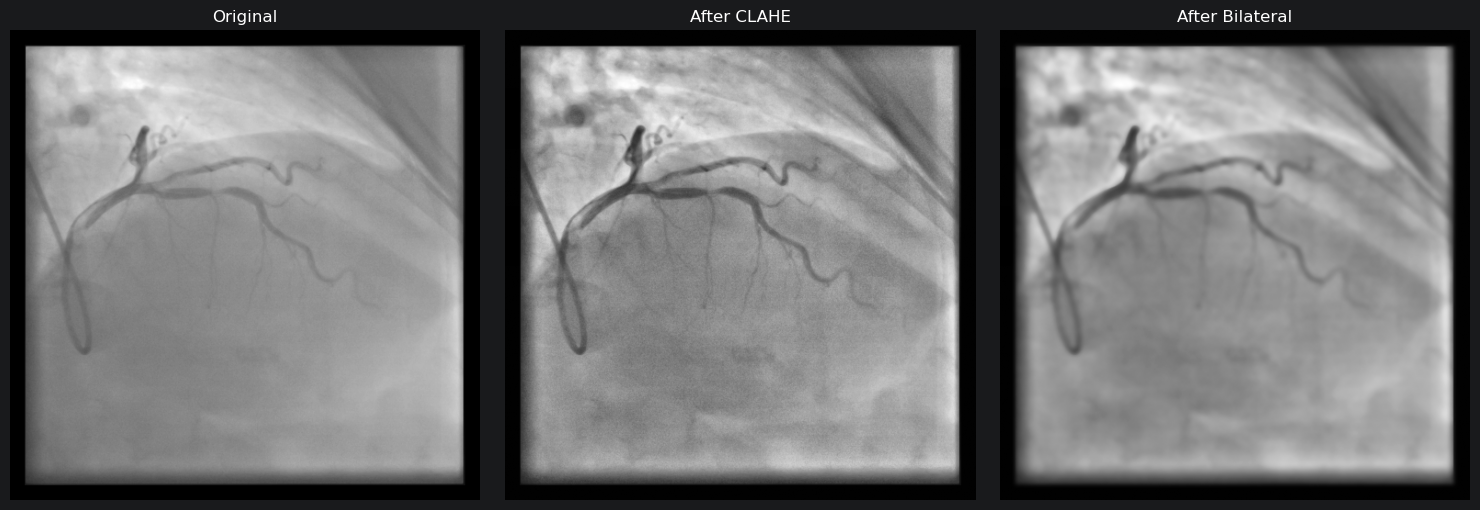

In [23]:
show_preprocessing(Path(r'C:\Users\jcgon\PycharmProjects\IPA_ML_StenosisDetection_Project\organized_dataset\002\5\14_002_5_0021.png'))

In [ ]:
print("""
# 1. Preview preprocessing:
show_preprocessing(Path('dataset/patient_001/session_01/frame_0001.png'))

# 2. Preview segmentation:
show_segmentation(Path('dataset/patient_001/session_01/frame_0001.png'))

# 3. Preview ROIs with GT boxes:
show_rois(Path('dataset/patient_001/session_01/frame_0001.png'))

# 4. Full pipeline summary (one figure):
show_pipeline_summary(Path('dataset/patient_001/session_01/frame_0001.png'))

# 5. Run on entire dataset (saves patches to disk):
meta_list = process_dataset(CFG, save_patches=True)

# 6. Quick test on first 5 frames:
meta_list = process_dataset(CFG, save_patches=False, max_frames=5)

# 7. Tweak config:
CFG.roi_size = 96
CFG.frangi_scale_range = (1.0, 8.0)
CFG.clahe_clip_limit = 3.0
""")